In [ ]:
# ──────────────────────────────────────────────────────────────────────
# FODO LATTICE DESIGN
# Accelerator Physics Course - ALBA Synchrotron
# MAY 2026
# ──────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# OPA DATA ──────────────────────────────────────────────────────────────────────
# Data collected using OPA software implementing a FODO lattice

# k_QF stable solution with fixed k_QD = -1.2 m^{-2}
kQF   = np.array([1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2])
dQF_TuneX = np.array([3.68455, 5.55289, 7.05680, 8.42410, 9.75298, 11.11905, 12.62240])
dQF_TuneY = np.array([6.59704, 6.05004, 5.46916, 4.84029, 4.13964,  3.31996,  2.25211])

# k_QD stable solution with fixed k_QF = +1.2 m^{-2}
kQD   = np.array([-2, -1.8, -1.6, -1.4, -1.2, -1.0, -0.8])
dQD_TuneX = np.array([2.22692, 3.33834, 4.18436, 4.90579, 5.55289, 6.15071, 6.71403])
dQD_TuneY = np.array([11.41297, 10.06550, 8.66108, 7.45906, 6.05004, 4.39408, 1.84439])

# Tune change with QF and QD



# Quad Strength $k_{QF,QD}$ vs Tune $Q$
When increasing $k_{QF}$, we observe that $Q_x$ increases rapidly and $Q_y$ decreases. A focusing quadrupole QF focuses horizontally, in the X plane, and defocuses vertically, in the Y plane, by construction.  In a FODO cell, the tune change is given by $\\$
>$
\Delta Q_x = \frac{1}{4\pi}\int \beta_x(s)\,\Delta k(s)\, ds
$  $\\$
$
\Delta Q_y = -\frac{1}{4\pi}\int \beta_y(s)\,\Delta k(s)\, ds
$  $\\$

and the QF is located where $\beta_x$ is large and $\beta_y$ is small, therefore $\Delta Q_x$ is larger while $\Delta Q_y$ is smaller. Consequently, the QF is more efficient at changing the tune in the horizontal plane X. $\\$
The defocusing quadrupole QD behaves analogously, but whit planes exchanged,  and is therefore more efficient at changing the tune in the vertical plane Y. 


 ─────── QF ───────
═══════════════════════════════════════════════════════
  LINEAR REGRESSION  Qₓ = m·k + b
  m  =  7.2575
  b  =  -3.2959
  R² =  0.997338       p = 1.24e-07
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  LINEAR REGRESSION  Qᵧ = m·k + b
  m  =  -3.5401
  b  =  10.3310
  R² =  0.985978       p = 7.94e-06
═══════════════════════════════════════════════════════


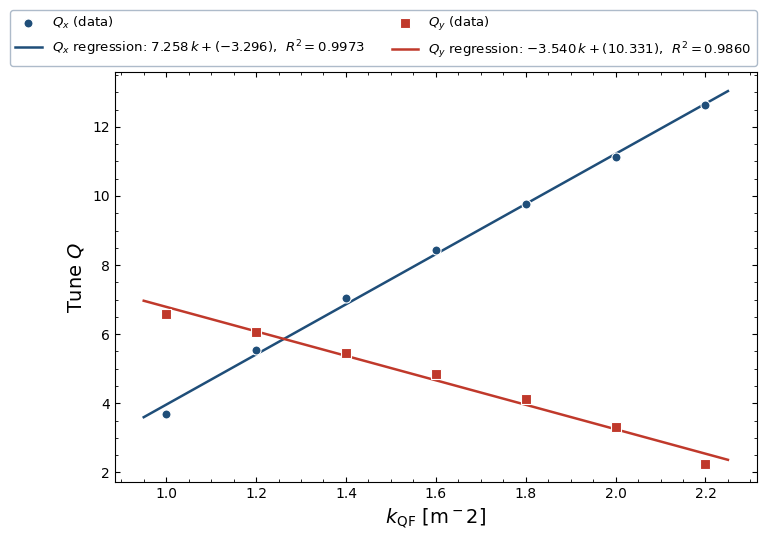


 ─────── QD ───────
═══════════════════════════════════════════════════════
  LINEAR REGRESSION  Qₓ = m·k + b
  m  =  3.6526
  b  =  9.8384
  R² =  0.985492       p = 8.65e-06
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  LINEAR REGRESSION  Qᵧ = m·k + b
  m  =  -7.6178
  b  =  -3.5382
  R² =  0.984724       p = 9.85e-06
═══════════════════════════════════════════════════════


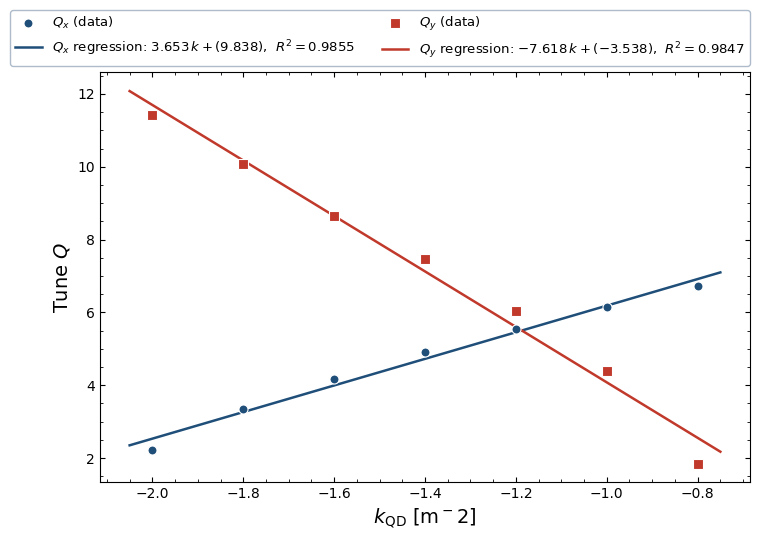

In [56]:

# SCAN k_QF and k_QD ──────────────────────────────────────────────────────────────────────
# k vs tune representation
def ajuste_lineal(x, y):
    n = len(x)
    slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
    y_pred = slope * x + intercept
    s_res  = np.sqrt(np.sum((y - y_pred)**2) / (n - 2))
    Sxx    = np.sum((x - x.mean())**2)
    d_slope     = s_res / np.sqrt(Sxx)
    d_intercept = s_res * np.sqrt(np.sum(x**2) / (n * Sxx))
    return slope, intercept, r_value**2, p_value, d_slope, d_intercept

def plot_tune(kQ, TuneX, TuneY, name):
    mX, bX, r2X, pvX, dmX, dbX = ajuste_lineal(kQ, TuneX)
    mY, bY, r2Y, pvY, dmY, dbY = ajuste_lineal(kQ, TuneY)

    print("═" * 55)
    print("  LINEAR REGRESSION  Qₓ = m·k + b")
    print(f"  m  =  {mX:.4f}")
    print(f"  b  =  {bX:.4f}")
    print(f"  R² =  {r2X:.6f}       p = {pvX:.2e}")
    print("═" * 55)
    print()
    print("═" * 55)
    print("  LINEAR REGRESSION  Qᵧ = m·k + b")
    print(f"  m  =  {mY:.4f}")
    print(f"  b  =  {bY:.4f}")
    print(f"  R² =  {r2Y:.6f}       p = {pvY:.2e}")
    print("═" * 55)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    x_fit = np.linspace(kQ.min() - 0.05, kQ.max() + 0.05, 300)

    # ── Tune X ────────────────────────────────────────────────────────────────────
    ax.plot(kQ, TuneX, 'o',
            color='#1f4e79', markersize=6.5, markeredgecolor='white',
            markeredgewidth=0.8, zorder=4, label=r"$Q_x$ (data)")
    yX_fit = mX * x_fit + bX
    ax.plot(x_fit, yX_fit, '-', color='#1f4e79', linewidth=1.8, zorder=3,
            label=(rf"$Q_x$ regression: ${mX:.3f}\,k + ({bX:.3f})$, "+ rf" $R^2={r2X:.4f}$"))

    # ── Tune Y ────────────────────────────────────────────────────────────────────
    ax.plot(kQ, TuneY, 's',
            color='#c0392b', markersize=6.5, markeredgecolor='white',
            markeredgewidth=0.8, zorder=4, label=r"$Q_y$ (data)")
    yY_fit = mY * x_fit + bY
    ax.plot(x_fit, yY_fit, '-', color='#c0392b', linewidth=1.8, zorder=3,
            label=(rf"$Q_y$ regression: ${mY:.3f}\,k + ({bY:.3f})$, "+ rf" $R^2={r2Y:.4f}$"))

    # ── Estilo científico ─────────────────────────────────────────────────────────

    ax.set_xlabel(rf"$k_\mathrm{{{name}}}$ [m$^{-2}$]", fontsize=14)
    ax.set_ylabel(r"Tune $Q$", fontsize=14)
    ax.legend(fontsize=9.5, framealpha=0.95, edgecolor='#aab8c8', loc='lower right', bbox_to_anchor=(1.01, 1),ncols=2)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.minorticks_on()

    plt.tight_layout()
    plt.savefig(f"Tunes_{name}.png", dpi=400, bbox_inches='tight')
    plt.show()


print("\n ─────── QF ───────")
plot_tune(kQF, dQF_TuneX, dQF_TuneY, "QF")


print("\n ─────── QD ───────")
plot_tune(kQD, dQD_TuneX, dQD_TuneY, "QD")
